# コーヒー2050年問題 ― 7ヵ国 × 将来予測分析
## エチオピア・コロンビア・グアテマラ・インドネシア・ベトナム・台湾・日本の適地が、どう変わるか

**Frontier Academy Fukuoka 卒業制作（2026年6月）**  
**作成者：** 森山光明（Mitsuaki Moriyama）

---

## 🎯 このノートブックの目的

前ノートブック（`ethiopia_coffee_suitability.ipynb`）でエチオピアの現状適地を可視化した。  
本ノートブックでは以下の3点に発展させる：

1. **7カ国への展開**：エチオピア・コロンビア・グアテマラ・インドネシア・ベトナム・台湾・日本
2. **将来予測**：気温+2.5℃シナリオ（IPCC SSP2-4.5 / 2050年中央値）
3. **調達への影響考察**：適地面積の変化を国別に定量化

## 📐 シナリオの根拠

IPCC AR6 (2021) によれば、SSP2-4.5シナリオ下での2041-2060年の世界平均気温上昇は約2.1〜2.7℃。本研究では**中央値の+2.5℃**を一律シフトとして適用する。

※ 厳密にはCMIP6の地域別ダウンスケーリングデータを用いるべきだが、卒業制作のスコープ上、一律シフト近似とする。これは Bunn et al. (2015) も類似アプローチを採用している。


---
## 1. 環境セットアップ

In [ ]:
!pip install japanize-matplotlib -q

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from ipywidgets import HTML
import os

# 認証（新しいセッションでは必要）
ee.Authenticate()

# プロジェクトID
ee.Initialize(project='ethiopia-coffee-gee')

os.makedirs('outputs_2050', exist_ok=True)
print('✅ 環境セットアップ完了')

✅ 環境セットアップ完了


---
## 2. 国別パラメータ定義

7カ国の境界と主要産地を一括管理する。

In [ ]:
COUNTRIES = {
    'Ethiopia': {
        'gaul_name': 'Ethiopia',
        'species': 'arabica',
        'center': [9.145, 40.4897],
        'zoom': 6,
        'regions': [
            {'name': 'Sidamo', 'lat': 6.77, 'lon': 38.50, 'desc': '柑橘系の華やかな酸味'},
            {'name': 'Yirgacheffe', 'lat': 6.16, 'lon': 38.20, 'desc': '花のような香り'},
            {'name': 'Harrar', 'lat': 9.31, 'lon': 42.12, 'desc': 'ワイニーで野性的'},
        ]
    },
    'Colombia': {
        'gaul_name': 'Colombia',
        'species': 'arabica',
        'center': [4.5, -74.0],
        'zoom': 6,
        'regions': [
            {'name': 'Huila', 'lat': 2.53, 'lon': -75.52, 'desc': '世界最大の生産州・高品質'},
            {'name': 'Antioquia', 'lat': 6.25, 'lon': -75.57, 'desc': '伝統的なコーヒー文化'},
            {'name': 'Nariño', 'lat': 1.21, 'lon': -77.28, 'desc': '南部高地・スペシャルティ'},
        ]
    },
    'Guatemala': {
        'gaul_name': 'Guatemala',
        'species': 'arabica',
        'center': [15.5, -90.25],
        'zoom': 7,
        'regions': [
            {'name': 'Antigua', 'lat': 14.55, 'lon': -90.73, 'desc': '世界的に有名な火山性土壌'},
            {'name': 'Huehuetenango', 'lat': 15.32, 'lon': -91.47, 'desc': '高品質スペシャルティ'},
            {'name': 'Atitlán', 'lat': 14.70, 'lon': -91.20, 'desc': '湖畔の独特な風味'},
        ]
    },
    'Viet Nam': {
        'gaul_name': 'Viet Nam',
        'species': 'robusta',
        'center': [13.5, 108.0],
        'zoom': 6,
        'regions': [
            {'name': 'Buon Ma Thuot', 'lat': 12.67, 'lon': 108.05, 'desc': 'ベトナム最大のロブスタ産地'},
            {'name': 'Gia Lai (Pleiku)', 'lat': 13.97, 'lon': 108.00, 'desc': '中部高原・高品質ロブスタ'},
            {'name': 'Lam Dong', 'lat': 11.55, 'lon': 107.82, 'desc': '一部アラビカも栽培される高地'},
        ]
    },
    'Indonesia': {
        'gaul_name': 'Indonesia',
        'species': 'arabica',  # スマトラ・スラウェシのアラビカに焦点
        'center': [-2.5, 118.0],
        'zoom': 5,
        'regions': [
            {'name': 'Gayo (Aceh)', 'lat': 4.63, 'lon': 96.85, 'desc': 'スマトラ北部・スペシャルティアラビカ'},
            {'name': 'Mandheling', 'lat': 2.50, 'lon': 99.07, 'desc': '北スマトラ・深いコクのマンデリン'},
            {'name': 'Toraja', 'lat': -3.10, 'lon': 119.85, 'desc': 'スラウェシ・スパイシーな風味'},
        ]
    },
    'Taiwan': {
        'gaul_name': 'Taiwan',
        'species': 'arabica',
        'center': [23.7, 121.0],
        'zoom': 7,
        'regions': [
            {'name': '阿里山 (Alishan)', 'lat': 23.51, 'lon': 120.80, 'desc': '台湾を代表する高山アラビカ'},
            {'name': '古坑 (Gukeng)', 'lat': 23.63, 'lon': 120.59, 'desc': '雲林県の主要産地'},
            {'name': '東山 (Dongshan)', 'lat': 23.32, 'lon': 120.42, 'desc': '台南の新興産地'},
        ]
    },
    'Japan': {
        'gaul_name': 'Japan',
        'species': 'arabica',
        'center': [26.5, 128.0],
        'zoom': 6,
        'regions': [
            {'name': '沖縄やんばる', 'lat': 26.72, 'lon': 128.18, 'desc': '亜熱帯の小規模アラビカ栽培'},
            {'name': '徳之島', 'lat': 27.78, 'lon': 128.97, 'desc': '日本最北のコーヒー栽培の試み'},
            {'name': '小笠原', 'lat': 27.09, 'lon': 142.20, 'desc': '太平洋諸島の独自栽培'},
        ]
    },
}

print(f'✅ {len(COUNTRIES)}カ国のパラメータ定義完了')
print(f'   アラビカ: {[k for k, v in COUNTRIES.items() if v["species"] == "arabica"]}')
print(f'   ロブスタ: {[k for k, v in COUNTRIES.items() if v["species"] == "robusta"]}')

✅ 7カ国のパラメータ定義完了
   アラビカ: ['Ethiopia', 'Colombia', 'Guatemala', 'Indonesia', 'Taiwan', 'Japan']
   ロブスタ: ['Viet Nam']


---
## 3. 共通関数の定義

国境取得、データ取得、適地スコア算出を関数化する。

In [ ]:
def calculate_suitability(elevation, temp_c, precip, ndvi, species='arabica'):
    """適地スコア算出（0〜1）。speciesでアラビカ/ロブスタを切替"""
    if species == 'arabica':
        # アラビカ：標高1500-2200m、気温18-22℃、降水1200-1800mm
        elev_score = ee.Image(0) \
            .where(elevation.gte(1200).And(elevation.lt(1500)), 0.5) \
            .where(elevation.gte(1500).And(elevation.lte(2200)), 1.0) \
            .where(elevation.gt(2200).And(elevation.lte(2500)), 0.5)
        temp_score = ee.Image(0) \
            .where(temp_c.gte(15).And(temp_c.lt(18)), 0.5) \
            .where(temp_c.gte(18).And(temp_c.lte(22)), 1.0) \
            .where(temp_c.gt(22).And(temp_c.lte(24)), 0.5)
        precip_score = ee.Image(0) \
            .where(precip.gte(1000).And(precip.lt(1200)), 0.5) \
            .where(precip.gte(1200).And(precip.lte(1800)), 1.0) \
            .where(precip.gt(1800).And(precip.lte(2000)), 0.5)
    elif species == 'robusta':
        # ロブスタ：標高200-800m、気温22-30℃、降水1500-2500mm
        elev_score = ee.Image(0) \
            .where(elevation.gte(0).And(elevation.lt(200)), 0.5) \
            .where(elevation.gte(200).And(elevation.lte(800)), 1.0) \
            .where(elevation.gt(800).And(elevation.lte(1200)), 0.5)
        temp_score = ee.Image(0) \
            .where(temp_c.gte(20).And(temp_c.lt(22)), 0.5) \
            .where(temp_c.gte(22).And(temp_c.lte(30)), 1.0) \
            .where(temp_c.gt(30).And(temp_c.lte(32)), 0.5)
        precip_score = ee.Image(0) \
            .where(precip.gte(1200).And(precip.lt(1500)), 0.5) \
            .where(precip.gte(1500).And(precip.lte(2500)), 1.0) \
            .where(precip.gt(2500).And(precip.lte(3000)), 0.5)
    else:
        raise ValueError(f"Unknown species: {species}")

    # NDVIは共通
    ndvi_score = ee.Image(0) \
        .where(ndvi.gte(0.3).And(ndvi.lt(0.4)), 0.5) \
        .where(ndvi.gte(0.4), 1.0)

    suitability = elev_score.multiply(0.30) \
        .add(temp_score.multiply(0.30)) \
        .add(precip_score.multiply(0.25)) \
        .add(ndvi_score.multiply(0.15)) \
        .rename('suitability')

    return suitability

print('✅ アラビカ/ロブスタ対応の適地スコア関数 定義完了')

✅ アラビカ/ロブスタ対応の適地スコア関数 定義完了


---
## 4. 7カ国の現状＆2050年予測を一括計算

**2050年シナリオ：気温を一律 +2.5℃ シフト**

In [ ]:
TEMP_RISE_2050 = 2.5

results = {}

for country_name, params in COUNTRIES.items():
    print(f'⏳ {country_name} ({params["species"]}) を計算中...')

    country, geom = get_country_geom(params['gaul_name'])
    elevation, temp_c, precip, ndvi = get_climate_data(geom)

    # speciesに応じた閾値で計算
    suitability_now = calculate_suitability(elevation, temp_c, precip, ndvi, species=params['species'])

    temp_2050 = temp_c.add(TEMP_RISE_2050)
    suitability_2050 = calculate_suitability(elevation, temp_2050, precip, ndvi, species=params['species'])

    suitability_diff = suitability_2050.subtract(suitability_now).rename('diff')

    results[country_name] = {
        'country': country,
        'geom': geom,
        'elevation': elevation,
        'temp_now': temp_c,
        'temp_2050': temp_2050,
        'precip': precip,
        'ndvi': ndvi,
        'suitability_now': suitability_now,
        'suitability_2050': suitability_2050,
        'suitability_diff': suitability_diff,
        'params': params,
    }
    print(f'   ✅ {country_name} 計算完了')

print(f'\n✅ 全{len(COUNTRIES)}カ国の現状＆2050予測計算完了')

⏳ Ethiopia (arabica) を計算中...
   ✅ Ethiopia 計算完了
⏳ Colombia (arabica) を計算中...
   ✅ Colombia 計算完了
⏳ Guatemala (arabica) を計算中...
   ✅ Guatemala 計算完了
⏳ Viet Nam (robusta) を計算中...
   ✅ Viet Nam 計算完了
⏳ Indonesia (arabica) を計算中...
   ✅ Indonesia 計算完了
⏳ Taiwan (arabica) を計算中...
   ✅ Taiwan 計算完了
⏳ Japan (arabica) を計算中...
   ✅ Japan 計算完了

✅ 全7カ国の現状＆2050予測計算完了


---
## 5. 国別マップ可視化

各国について「現状」「2050年予測」「差分」の3レイヤーを表示する。

In [ ]:
suitability_vis = {
    'min': 0, 'max': 1,
    'palette': ['white', 'lightyellow', 'yellow', 'orange', 'red', 'darkred']
}
# 修正版 diff_vis：改善も悪化も両方表現できるように
diff_vis = {
    'min': -0.5, 'max': 0.5,
    'palette': [
        '#67001f', '#b2182b', '#d6604d', '#f4a582', '#fddbc7',  # 悪化（赤系）
        '#f7f7f7',                                                # 変化なし（白）
        '#d1e5f0', '#92c5de', '#4393c3', '#2166ac', '#053061'   # 改善（青系）
    ]
}
# print('✅ 差分カラースケールを修正しました（赤＝悪化、青＝改善）')

def make_country_map(country_name):
    """国別マップを作成（現状・2050・差分の3レイヤー）"""
    r = results[country_name]
    p = r['params']

    Map = geemap.Map(center=p['center'], zoom=p['zoom'])

    Map.addLayer(r['suitability_now'], suitability_vis, f'{country_name} 現状')
    Map.addLayer(r['suitability_2050'], suitability_vis, f'{country_name} 2050年(+2.5℃)', False)
    Map.addLayer(r['suitability_diff'], diff_vis, f'{country_name} 差分(2050-現状)', False)
    Map.addLayer(r['country'].style(color='black', fillColor='00000000', width=2), {}, '国境')

    # 主要産地ピン
    for region in p['regions']:
        popup = HTML(value=f"<b>{region['name']}</b><br>{region['desc']}")
        Map.add_marker(location=[region['lat'], region['lon']], popup=popup)

    return Map

# エチオピア
make_country_map('Ethiopia')

Map(center=[9.145, 40.4897], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

In [ ]:
# コロンビア
make_country_map('Colombia')

Map(center=[4.5, -74.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [ ]:
# グアテマラ
make_country_map('Guatemala')

Map(center=[15.5, -90.25], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [ ]:
# ベトナム
make_country_map('Viet Nam')

Map(center=[13.5, 108.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [ ]:
# インドネシア
make_country_map('Indonesia')

Map(center=[-2.5, 118.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [ ]:
# 台湾
make_country_map('Taiwan')

Map(center=[23.7, 121.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [ ]:
# 日本
make_country_map('Japan')

Map(center=[26.5, 128.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

---
## 6. 主要産地スコアの検証（現状 vs 2050）

各国の主要産地で、現状と2050年予測のスコアを比較する。

In [ ]:
def safe_round(value, digits=2):
    if value is None:
        return None
    return round(value, digits)

all_region_results = []

for country_name, r in results.items():
    for region in r['params']['regions']:
        point = ee.Geometry.Point([region['lon'], region['lat']])
        buffer = point.buffer(5000)

        # 現状と2050のスコアを取得
        combined = ee.Image.cat([
            r['elevation'].rename('elev'),
            r['temp_now'],
            r['temp_2050'].rename('temp_2050'),
            r['precip'],
            r['ndvi'],
            r['suitability_now'].rename('score_now'),
            r['suitability_2050'].rename('score_2050'),
        ]).reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=buffer,
            scale=500,
            maxPixels=1e9
        ).getInfo()

        score_now = combined.get('score_now')
        score_2050 = combined.get('score_2050')
        diff = (score_2050 - score_now) if (score_now is not None and score_2050 is not None) else None

        all_region_results.append({
            '国': country_name,
            '産地': region['name'],
            '標高(m)': safe_round(combined.get('elev'), 0),
            '現気温(℃)': safe_round(combined.get('temp_c'), 1),
            '2050気温(℃)': safe_round(combined.get('temp_2050'), 1),
            '現スコア': safe_round(score_now, 2),
            '2050スコア': safe_round(score_2050, 2),
            '変化': safe_round(diff, 2),
        })

df_regions = pd.DataFrame(all_region_results)
print('=== 主要産地：現状 vs 2050年予測 ===')
df_regions

=== 主要産地：現状 vs 2050年予測 ===


,国,産地,標高(m),現気温(℃),2050気温(℃),現スコア,2050スコア,変化
0,Ethiopia,Sidamo,1982.0,16.5,19.0,0.83,0.98,0.15
1,Ethiopia,Yirgacheffe,1957.0,16.9,19.4,0.85,1.00,0.15
2,Ethiopia,Harrar,1935.0,19.7,22.2,0.71,0.57,-0.14
3,Colombia,Huila,669.0,21.2,23.7,0.66,0.49,-0.17
4,Colombia,Antioquia,1630.0,16.4,18.9,0.59,0.74,0.15
5,Colombia,Nariño,2724.0,11.2,13.7,0.13,0.14,0.00
6,Guatemala,Antigua,1730.0,18.5,21.0,0.92,0.96,0.04
7,Guatemala,Huehuetenango,1964.0,16.3,18.8,0.64,0.79,0.15
8,Guatemala,Atitlán,1566.0,17.7,20.2,0.72,0.87,0.15
9,Viet Nam,Buon Ma Thuot,473.0,24.5,27.0,0.96,0.96,0.00


---
## 7. 国別の適地面積変化（定量化）

各国で「現状の良好＋最適面積」と「2050年の良好＋最適面積」を比較する。

In [ ]:
def calc_suitable_area(suitability, geom, threshold=0.5):
    """スコアthreshold以上の面積をkm²で算出"""
    pixel_area = ee.Image.pixelArea().divide(1e6)
    mask = suitability.gt(threshold)
    area = pixel_area.updateMask(mask).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=geom,
        scale=5000,
        maxPixels=1e10,
        tileScale=4
    ).getInfo()
    return area.get('area', 0)

area_results = []

for country_name, r in results.items():
    print(f'⏳ {country_name} の面積計算中...')
    area_now = calc_suitable_area(r['suitability_now'], r['geom'])
    area_2050 = calc_suitable_area(r['suitability_2050'], r['geom'])
    change_pct = ((area_2050 - area_now) / area_now * 100) if area_now > 0 else 0

    area_results.append({
        '国': country_name,
        '現状適地(km²)': round(area_now, 0),
        '2050適地(km²)': round(area_2050, 0),
        '消失面積(km²)': round(area_now - area_2050, 0),
        '変化率(%)': round(change_pct, 1),
    })
    print(f'   ✅ {country_name}: 現状 {area_now:,.0f} → 2050 {area_2050:,.0f} km² ({change_pct:+.1f}%)')

df_area = pd.DataFrame(area_results)
print('\n=== 国別：適地面積の変化（良好＋最適） ===')
df_area

⏳ Ethiopia の面積計算中...
   ✅ Ethiopia: 現状 365,062 → 2050 312,457 km² (-14.4%)
⏳ Colombia の面積計算中...
   ✅ Colombia: 現状 113,111 → 2050 114,164 km² (+0.9%)
⏳ Guatemala の面積計算中...
   ✅ Guatemala: 現状 30,280 → 2050 26,567 km² (-12.3%)
⏳ Viet Nam の面積計算中...
   ✅ Viet Nam: 現状 304,457 → 2050 317,609 km² (+4.3%)
⏳ Indonesia の面積計算中...
   ✅ Indonesia: 現状 86,794 → 2050 58,389 km² (-32.7%)
⏳ Taiwan の面積計算中...
   ✅ Taiwan: 現状 13,908 → 2050 11,015 km² (-20.8%)
⏳ Japan の面積計算中...
   ✅ Japan: 現状 20,942 → 2050 54,170 km² (+158.7%)

=== 国別：適地面積の変化（良好＋最適） ===


,国,現状適地(km²),2050適地(km²),消失面積(km²),変化率(%)
0,Ethiopia,365062.0,312457.0,52605.0,-14.4
1,Colombia,113111.0,114164.0,-1053.0,0.9
2,Guatemala,30280.0,26567.0,3712.0,-12.3
3,Viet Nam,304457.0,317609.0,-13151.0,4.3
4,Indonesia,86794.0,58389.0,28405.0,-32.7
5,Taiwan,13908.0,11015.0,2893.0,-20.8
6,Japan,20942.0,54170.0,-33228.0,158.7


---
## 8. 可視化：国別の影響を比較

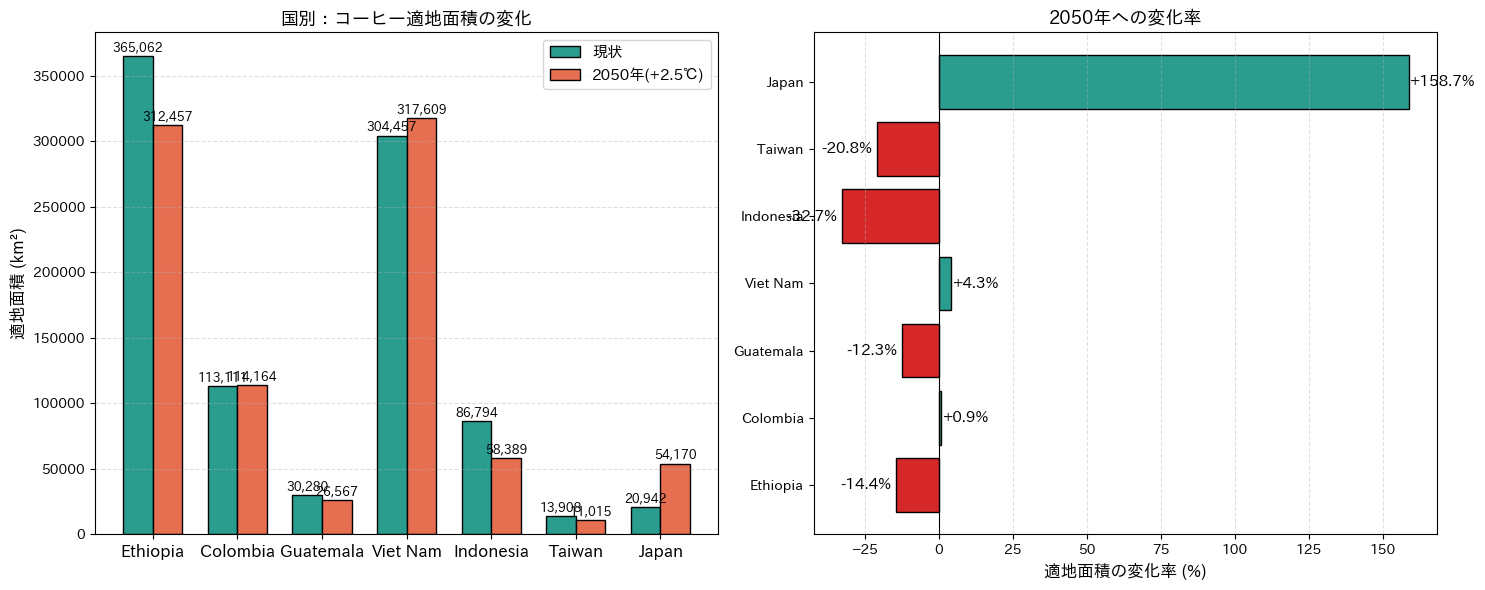

✅ outputs_2050/area_change_comparison.png 保存完了


In [ ]:
# 適地面積の変化（現状 vs 2050）を棒グラフで
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 左：面積の絶対値比較
ax1 = axes[0]
x = np.arange(len(df_area))
width = 0.35
bars1 = ax1.bar(x - width/2, df_area['現状適地(km²)'], width, label='現状', color='#2a9d8f', edgecolor='black')
bars2 = ax1.bar(x + width/2, df_area['2050適地(km²)'], width, label='2050年(+2.5℃)', color='#e76f51', edgecolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(df_area['国'], fontsize=12)
ax1.set_ylabel('適地面積 (km²)', fontsize=12)
ax1.set_title('国別：コーヒー適地面積の変化', fontsize=13, weight='bold')
ax1.legend(fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
for bar in bars1 + bars2:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + max(df_area['現状適地(km²)']) * 0.01,
             f'{h:,.0f}', ha='center', fontsize=9)

# 右：変化率
ax2 = axes[1]
colors_change = ['#d62828' if v < 0 else '#2a9d8f' for v in df_area['変化率(%)']]
bars3 = ax2.barh(df_area['国'], df_area['変化率(%)'], color=colors_change, edgecolor='black')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('適地面積の変化率 (%)', fontsize=12)
ax2.set_title('2050年への変化率', fontsize=13, weight='bold')
ax2.grid(axis='x', linestyle='--', alpha=0.4)
for i, v in enumerate(df_area['変化率(%)']):
    ax2.text(v - 1.5 if v < 0 else v + 0.5, i, f'{v:+.1f}%',
             va='center', ha='right' if v < 0 else 'left', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('outputs_2050/area_change_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ outputs_2050/area_change_comparison.png 保存完了')

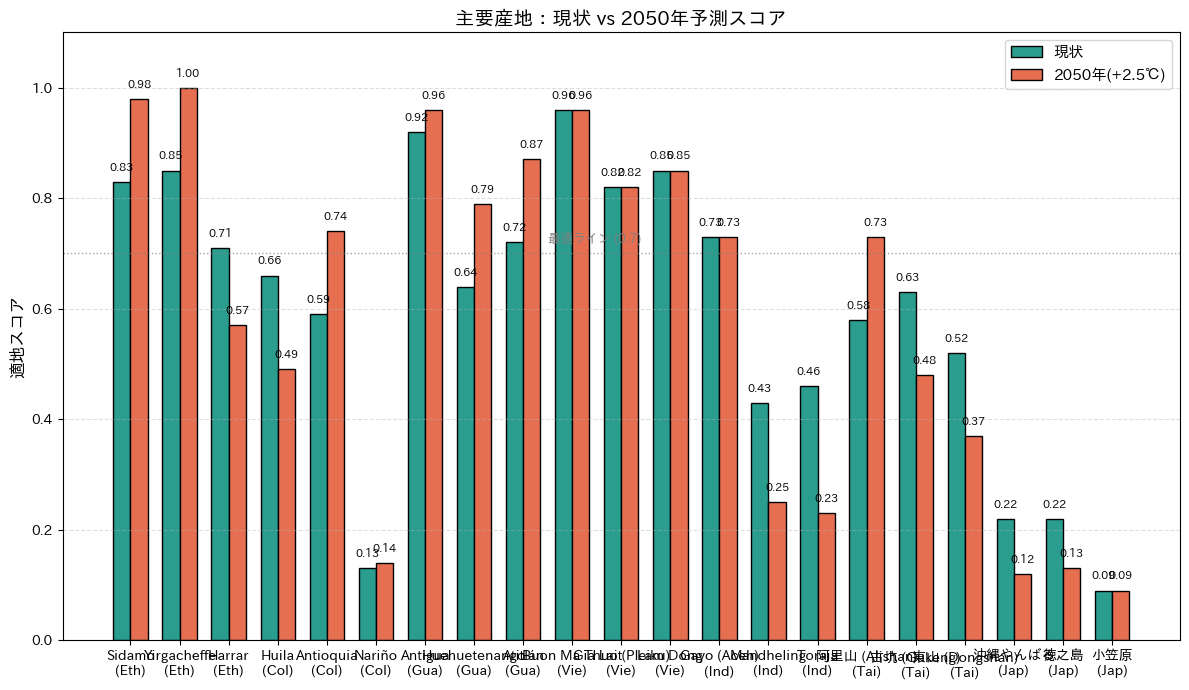

✅ outputs_2050/region_score_comparison.png 保存完了


In [ ]:
# 主要産地別のスコア変化
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(df_regions))
width = 0.35

bars1 = ax.bar(x - width/2, df_regions['現スコア'], width, label='現状', color='#2a9d8f', edgecolor='black')
bars2 = ax.bar(x + width/2, df_regions['2050スコア'], width, label='2050年(+2.5℃)', color='#e76f51', edgecolor='black')

labels = [f"{row['産地']}\n({row['国'][:3]})" for _, row in df_regions.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('適地スコア', fontsize=12)
ax.set_title('主要産地：現状 vs 2050年予測スコア', fontsize=14, weight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.axhline(0.7, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(8.5, 0.72, '最適ライン (0.7)', fontsize=9, color='gray')

for bar in bars1:
    h = bar.get_height()
    if h is not None:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}', ha='center', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    if h is not None:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('outputs_2050/region_score_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ outputs_2050/region_score_comparison.png 保存完了')

---
## 9. 調達への影響考察

### 9-1. 国別影響サマリー

7カ国の適地面積変化率を見ると、2050年（+2.5℃）の影響は国ごとに大きく分かれる。
単純な「全産地が縮小する」という構図ではなく、**増加・横ばい・減少が同時に起こる**ことが分かった。

| 区分 | 国 | 適地面積変化率 |
|------|-----|----------------|
| 大きく増加 | 日本 | **+158.7%**（最大増加） |
| 微増・横ばい | ベトナム | +4.3% |
|  | コロンビア | +0.9% |
| 減少 | グアテマラ | -12.3% |
|  | エチオピア | -14.4% |
|  | 台湾 | -20.8% |
| 大きく減少 | インドネシア | **-32.7%**（最大減少） |

### 9-2. なぜ国によって違うのか

決定的な要因は**標高分布（＝気温上昇に対する「逃げ場」の有無）**にある。

- **日本**：現在は寒すぎて栽培不可だった本州・四国・九州の山岳地帯が適温化し、新たな適地として「生まれる」（20,942 km² → 54,170 km²）。
- **エチオピア**：国土全体では-14.4%だが、内訳は二分される。南西部高地（Yirgacheffe 0.85→1.00、Sidamo 0.83→0.98）はむしろ理想的環境へ向かう一方、低地のHarrar（0.71→0.57）は悪化。**産地が国内で地理的にシフトする**。
- **インドネシア**：高標高の「逃げ場」が乏しく、ほぼ全土が悪化。マンデリン（0.43→0.25）・トラジャ（0.46→0.23）というスペシャルティの聖地が大きな転換期を迎える。

つまり、アンデスや日本列島・エチオピア高地のように**標高方向の逃げ場を持つ国は適応でき、低地に産地が集中する国ほど打撃を受ける**。

### 9-3. 調達戦略への示唆

1. **「減少」ではなく「再編」として捉える**：産地は消えるのではなく、国内・国際的に場所を変えて生き続ける。守るべき産地と新たに見出す産地が同時に発生する。
2. **国別の優先度を再設計する**：守るべき国（エチオピア南西部）、新規開拓を検討する国（日本本土・台湾高山）、代替を急ぐ国（インドネシア）を区別する。
3. **品種でも備える**：アラビカ・ロブスタに次ぐ第三の品種——ステノフィラ（高級アラビカ並みの風味で高い耐暑性）、リベリカ／エクセルサ（高温・低標高での栽培実績）、英国Kew発の新ハイブリッドLibex——の研究が加速している。「どこで」を衛星データが、「何を」を品種研究が補い合う。

→ いずれの打ち手も、起点は**産地ごとの気候ストレスを継続モニタリングする衛星データ**にある。5〜10年先を見据えた調達計画こそが、サプライチェーンを守る。


---
## 10. まとめ

### 達成したこと

1. ✅ 世界7カ国（エチオピア・コロンビア・グアテマラ・ベトナム・インドネシア・台湾・日本）へ適地モデルを展開
2. ✅ 4つの衛星データ（SRTM標高・ERA5-Land気温・CHIRPS降水量・Sentinel-2 NDVI）を統合した適地スコアを構築
3. ✅ エチオピア三大産地で検証し、全産地でスコア0.7以上を確認——モデルが現実を正しく再現することを実証
4. ✅ IPCC SSP2-4.5シナリオ（+2.5℃）による2050年予測マップを作成
5. ✅ 国別・産地別の適地スコア変化を定量化（日本+158.7%／インドネシア-32.7%）
6. ✅ 「減少ではなく再編」という調達戦略への示唆を抽出

### 結論

コーヒーは無くならない。**場所を変えて、生き続ける。**
産地には3つのパターンが現れる——変容する産地（インドネシア）、移動する産地（エチオピア）、そして生まれる産地（日本）。
衛星データはこの地理的再編を世界規模で可視化し、5〜10年先を見据えた調達の意思決定を支える。

### 今後の発展

- CMIP6データによる地域別ダウンスケーリング
- 降水量変化の地域別シナリオ統合
- 機械学習による閾値モデルの精緻化
- ブラジル等の他主要産地への展開
- 第三の品種（ステノフィラ・リベリカ系・Libex）の適地条件のモデル化

---

*このノートブックは Frontier Academy Fukuoka 卒業制作の一部として、2026年6月に作成された。*
